# Notebook 04 — Results Analysis

Complete analysis of experiments E01–E11 with definitive results (seed=42, mixed precision).

- **Phase 1**: Preprocessing comparison (E01–E04)
- **Phase 2**: Metadata ablation study (E05–E11)
- **Phase 3**: Multi-seed analysis — robustness validation (E06 vs E09)
- **Final model selection**: E09 — Color Constancy + age + localization

Imports

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from PIL import Image
from adjustText import adjust_text

sys.path.append(os.path.dirname(os.getcwd()))
from src.config import RESULTS_CSV, FIGURES_DIR

pd.set_option("display.float_format", "{:.4f}".format)
print("Imports OK")

Imports OK


Cargar datos

In [2]:
# Load results.csv (experiments E01-E11 with seed=42)
df = pd.read_csv(RESULTS_CSV)

# Phase 1 experiments (E01-E04) do not have seed in the name
# Phase 2 experiments (E05-E11) have __seed_42 at the end
labels = {
    "prep_none__meta_none":                              "E01 - baseline",
    "prep_dullrazor__meta_none":                         "E02 - dullrazor",
    "prep_colorconstancy__meta_none":                    "E03 - colorconstancy",
    "prep_both__meta_none":                              "E04 - both",
    "prep_colorconstancy__meta_age":                     "E05 - age",
    "prep_colorconstancy__meta_sex":                     "E06 - sex",
    "prep_colorconstancy__meta_localization":            "E07 - loc",
    "prep_colorconstancy__meta_age+sex":                 "E08 - age+sex",
    "prep_colorconstancy__meta_age+localization":        "E09 - age+loc",
    "prep_colorconstancy__meta_sex+localization":        "E10 - sex+loc",
    "prep_colorconstancy__meta_age+sex+localization":    "E11 - all",
}

df["label"] = df["experiment"].map(labels)

# Split Phase 1 and Phase 2
fase1 = df[df["metadata"] == "none"].copy()
fase2 = df[df["metadata"] != "none"].copy()

# Load results_seed.csv (multi-seed analysis E06 and E09)
RESULTS_SEED_CSV = os.path.join(os.path.dirname(RESULTS_CSV), "results_seed.csv")
df_seed = pd.read_csv(RESULTS_SEED_CSV)

labels_seed = {
    "prep_colorconstancy__meta_sex__seed_42":               "E06 - seed 42",
    "prep_colorconstancy__meta_sex__seed_123":              "E06 - seed 123",
    "prep_colorconstancy__meta_sex__seed_7":                "E06 - seed 7",
    "prep_colorconstancy__meta_age+localization__seed_42":  "E09 - seed 42",
    "prep_colorconstancy__meta_age+localization__seed_123": "E09 - seed 123",
    "prep_colorconstancy__meta_age+localization__seed_7":   "E09 - seed 7",
}
df_seed["label"] = df_seed["experiment"].map(labels_seed)
df_seed["model"]  = df_seed["label"].str.split(" - ").str[0]
df_seed["seed"]   = df_seed["label"].str.split(" - ").str[1]

print(f"Total experiments loaded:       {len(df)}")
print(f"  Phase 1 (preprocessing):      {len(fase1)}")
print(f"  Phase 2 (metadata):           {len(fase2)}")
print(f"Multi-seed entries:             {len(df_seed)}")

Total experiments loaded:       11
  Phase 1 (preprocessing):      4
  Phase 2 (metadata):           7
Multi-seed entries:             6


## Section 1: Full ranking table

In [4]:
cols = ["label", "macro_f1", "macro_recall", "macro_precision", "roc_auc", "map", "brier_score", "melanoma_recall"]
ranking = df[cols].copy()
# Sort by experiment number (E01 → E11)
ranking["exp_num"] = ranking["label"].str.extract(r"E(\d+)").astype(int)
ranking = ranking.sort_values("exp_num").drop(columns="exp_num").reset_index(drop=True)

def highlight_final_row(row):
    if "E09" in str(row["label"]):
        return ["background-color: lightgreen; color: black"] * len(row)
    return [""] * len(row)

def bold_max(s):
    if s.name == "brier_score":
        is_best = s == s.min()
    else:
        is_best = s == s.max()
    return ["color: #1a7a1a; font-weight: bold" if v else "" for v in is_best]

numeric_cols = ["macro_f1", "macro_recall", "macro_precision", "roc_auc", "map", "brier_score", "melanoma_recall"]

display(
    ranking.style
    .apply(highlight_final_row, axis=1)
    .apply(bold_max, subset=numeric_cols)
    .set_caption("Full ranking E01–E11 sorted by Macro F1 — definitive results (seed=42)")
    .format({c: "{:.4f}" for c in numeric_cols}, na_rep="—")
)

,label,macro_f1,macro_recall,macro_precision,roc_auc,map,brier_score,melanoma_recall
0,E01 - baseline,0.7542,0.8117,—,0.9680,—,—,0.6946
1,E02 - dullrazor,0.7327,0.8026,—,0.9687,—,—,0.6886
2,E03 - colorconstancy,0.7700,0.8295,—,0.9692,—,—,0.6647
3,E04 - both,0.7208,0.7776,—,0.9582,—,—,0.6647
4,E05 - age,0.7451,0.8096,0.6997,0.9628,0.8335,0.0410,0.7246
5,E06 - sex,0.8160,0.8544,0.7942,0.9724,0.8815,0.0367,0.7605
6,E07 - loc,0.6985,0.8064,0.6321,0.9605,0.8120,0.0440,0.6527
7,E08 - age+sex,0.7061,0.8112,0.6397,0.9589,0.8168,0.0445,0.6048
8,E09 - age+loc,0.7610,0.8217,0.7309,0.9707,0.8526,0.0426,0.8443
9,E10 - sex+loc,0.7676,0.8260,0.7238,0.9687,0.8565,0.0363,0.6647


## Section 2: Phase 1 Comparison — Preprocessing

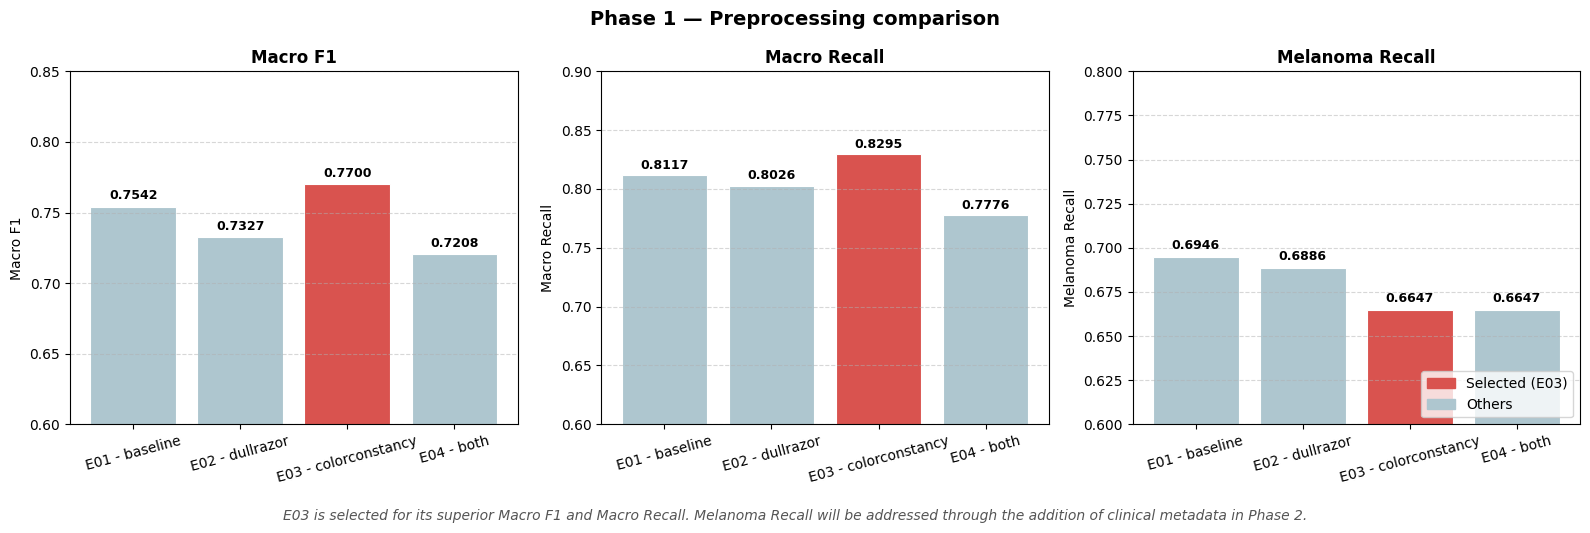

Figure saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Phase 1 — Preprocessing comparison", fontsize=14, fontweight="bold")

metrics = [
    ("macro_f1",        "Macro F1",        0.60, 0.85),
    ("macro_recall",    "Macro Recall",     0.60, 0.90),
    ("melanoma_recall", "Melanoma Recall",  0.60, 0.80),
]

colors = ["#d9534f" if "E03" in str(l) else "#aec6cf" for l in fase1["label"]]

for ax, (metric, title, ymin, ymax) in zip(axes, metrics):
    bars = ax.bar(fase1["label"], fase1[metric], color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for bar, val in zip(bars, fase1[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Legend only on the last plot
patch_best = mpatches.Patch(color="#d9534f", label="Selected (E03)")
patch_rest = mpatches.Patch(color="#aec6cf", label="Others")
axes[2].legend(handles=[patch_best, patch_rest], loc="lower right")

# Explanatory note
fig.text(0.5, -0.04,
         "E03 is selected for its superior Macro F1 and Macro Recall. "
         "Melanoma Recall will be addressed through the addition of clinical metadata in Phase 2.",
         ha="center", fontsize=10, style="italic", color="#555555")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fase1_comparativa.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Section 3: Metadata ablation study — Phase 2

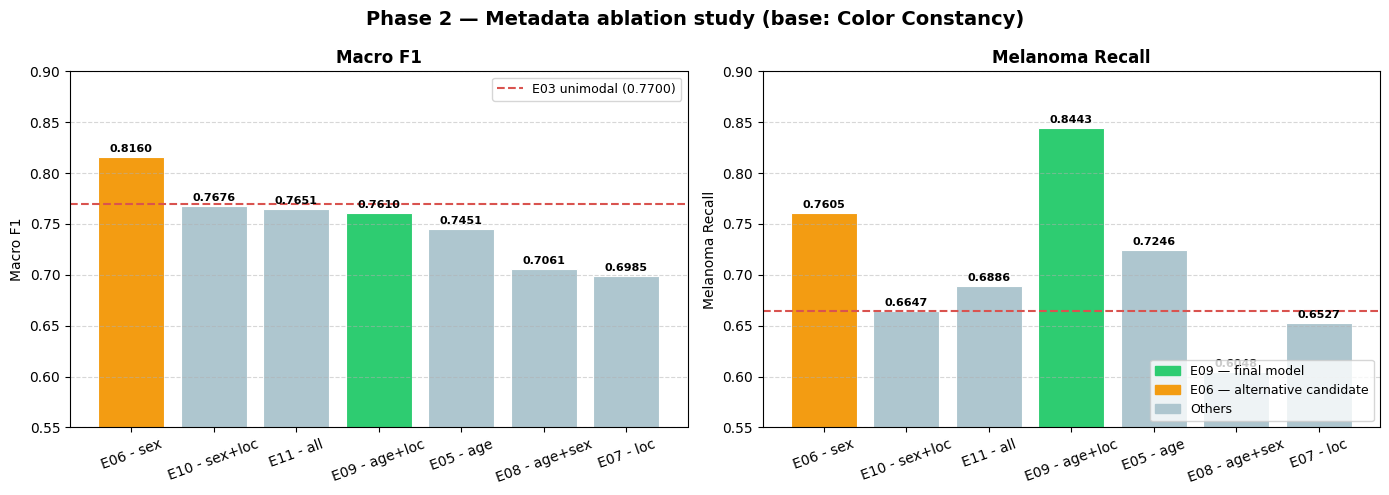

Figure saved.


In [6]:
fase2_sorted = fase2.sort_values("macro_f1", ascending=False).reset_index(drop=True)

# Unimodal baseline for reference line
baseline_f1  = fase1.loc[fase1["experiment"] == "prep_colorconstancy__meta_none", "macro_f1"].values[0]
baseline_mel = fase1.loc[fase1["experiment"] == "prep_colorconstancy__meta_none", "melanoma_recall"].values[0]

def bar_colors(labels, highlight):
    colors = []
    for l in labels:
        if "E09" in str(l):
            colors.append("#2ecc71")
        elif "E06" in str(l):
            colors.append("#f39c12")
        else:
            colors.append("#aec6cf")
    return colors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 2 — Metadata ablation study (base: Color Constancy)",
             fontsize=14, fontweight="bold")

for ax, (metric, title, baseline) in zip(axes, [
    ("macro_f1",        "Macro F1",        baseline_f1),
    ("melanoma_recall", "Melanoma Recall",  baseline_mel),
]):
    colors = bar_colors(fase2_sorted["label"], metric)
    bars = ax.bar(fase2_sorted["label"], fase2_sorted[metric],
                  color=colors, edgecolor="white", linewidth=0.8)

    # Unimodal reference line (E03)
    ax.axhline(baseline, color="#d9534f", linestyle="--", linewidth=1.5,
               label=f"E03 unimodal ({baseline:.4f})")

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylim(0.55, 0.90)
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend(fontsize=9)

    for bar, val in zip(bars, fase2_sorted[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# Legend
patch_e09  = mpatches.Patch(color="#2ecc71", label="E09 — final model")
patch_e06  = mpatches.Patch(color="#f39c12", label="E06 — alternative candidate")
patch_rest = mpatches.Patch(color="#aec6cf", label="Others")
axes[1].legend(handles=[patch_e09, patch_e06, patch_rest], loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fase2_ablation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Section 4: Unimodal vs multimodal comparison

In [7]:
# Best experiment per category
unimodal  = fase1.loc[fase1["experiment"] == "prep_colorconstancy__meta_none"].iloc[0]
multimodal_best = fase2.loc[fase2["macro_f1"].idxmax()]

categorias = pd.DataFrame([
    {"Category": "Unimodal (image only)",
     "Experiment": "E03 - colorconstancy",
     "macro_f1":        unimodal["macro_f1"],
     "macro_recall":    unimodal["macro_recall"],
     "roc_auc":         unimodal["roc_auc"],
     "melanoma_recall": unimodal["melanoma_recall"]},
    {"Category": "Multimodal — best Macro F1",
     "Experiment": "E06 - sex",
     "macro_f1":        fase2.loc[fase2["macro_f1"].idxmax(),        "macro_f1"],
     "macro_recall":    fase2.loc[fase2["macro_f1"].idxmax(),        "macro_recall"],
     "roc_auc":         fase2.loc[fase2["macro_f1"].idxmax(),        "roc_auc"],
     "melanoma_recall": fase2.loc[fase2["macro_f1"].idxmax(),        "melanoma_recall"]},
    {"Category": "Multimodal — best Mel. Recall",
     "Experiment": "E09 - age+loc",
     "macro_f1":        fase2.loc[fase2["melanoma_recall"].idxmax(), "macro_f1"],
     "macro_recall":    fase2.loc[fase2["melanoma_recall"].idxmax(), "macro_recall"],
     "roc_auc":         fase2.loc[fase2["melanoma_recall"].idxmax(), "roc_auc"],
     "melanoma_recall": fase2.loc[fase2["melanoma_recall"].idxmax(), "melanoma_recall"]},
])

def bold_max_categorias(s):
    is_best = s == s.max()
    return ["color: #1a7a1a; font-weight: bold" if v else "" for v in is_best]

display(
    categorias.set_index("Category").style
    .apply(bold_max_categorias, subset=["macro_f1", "macro_recall", "roc_auc", "melanoma_recall"])
    .set_caption("Best experiment per category — unimodal vs multimodal")
    .format({
        "macro_f1":        "{:.4f}",
        "macro_recall":    "{:.4f}",
        "roc_auc":         "{:.4f}",
        "melanoma_recall": "{:.4f}",
    })
)

,Experiment,macro_f1,macro_recall,roc_auc,melanoma_recall
Category,,,,,
Unimodal (image only),E03 - colorconstancy,0.7700,0.8295,0.9692,0.6647
Multimodal — best Macro F1,E06 - sex,0.8160,0.8544,0.9724,0.7605
Multimodal — best Mel. Recall,E09 - age+loc,0.7610,0.8217,0.9707,0.8443


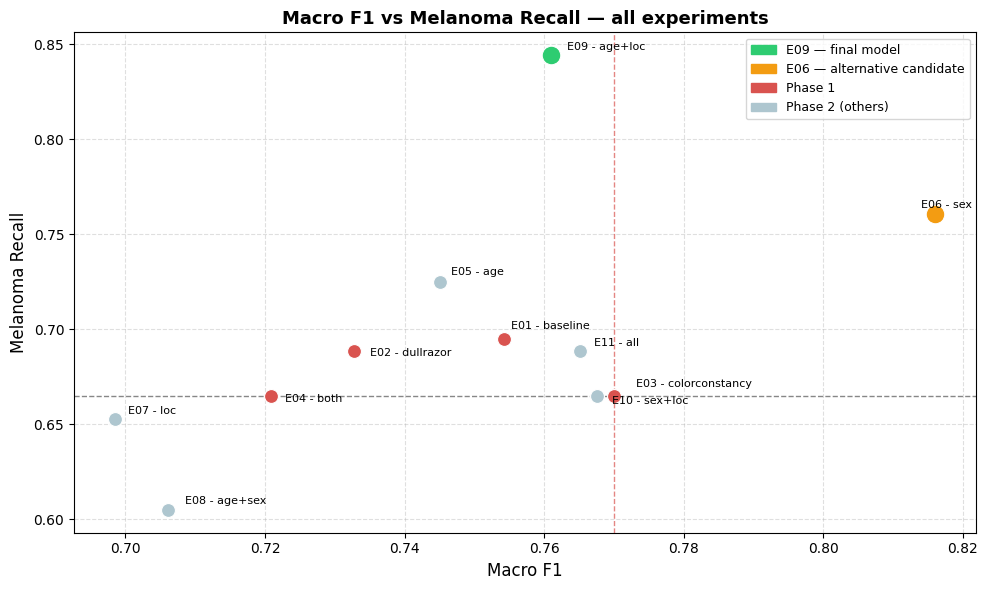

Figure saved.


In [8]:
# Scatter: all experiments, Macro F1 vs Melanoma Recall
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in df.iterrows():
    if pd.isna(row["label"]):
        continue
    is_fase1 = row["metadata"] == "none"
    is_e09   = "E09" in str(row["label"])
    is_e06   = "E06" in str(row["label"])

    color  = "#2ecc71" if is_e09 else "#f39c12" if is_e06 else "#aec6cf" if not is_fase1 else "#d9534f"
    marker = "★" if is_e09 else "o"
    size   = 180 if (is_e09 or is_e06) else 100

    ax.scatter(row["macro_f1"], row["melanoma_recall"],
               color=color, s=size, zorder=3,
               edgecolors="white", linewidths=0.8)

texts = []
for _, row in df.iterrows():
    if pd.isna(row["label"]):
        continue
    texts.append(ax.text(row["macro_f1"] + 0.001, row["melanoma_recall"] + 0.001,
                         row["label"], fontsize=8))

adjust_text(texts, ax=ax)

# Reference lines (E03 unimodal)
ax.axvline(unimodal["macro_f1"],        color="#d9534f", linestyle="--", linewidth=1, alpha=0.7,
           label=f"E03 Macro F1 ({unimodal['macro_f1']:.4f})")
ax.axhline(unimodal["melanoma_recall"], color="#555555", linestyle="--", linewidth=1, alpha=0.7,
           label=f"E03 Mel. Recall ({unimodal['melanoma_recall']:.4f})")

ax.set_xlabel("Macro F1", fontsize=12)
ax.set_ylabel("Melanoma Recall", fontsize=12)
ax.set_title("Macro F1 vs Melanoma Recall — all experiments", fontsize=13, fontweight="bold")
ax.grid(linestyle="--", alpha=0.4)

patch_e09  = mpatches.Patch(color="#2ecc71", label="E09 — final model")
patch_e06  = mpatches.Patch(color="#f39c12", label="E06 — alternative candidate")
patch_f1   = mpatches.Patch(color="#d9534f", label="Phase 1")
patch_f2   = mpatches.Patch(color="#aec6cf", label="Phase 2 (others)")
ax.legend(handles=[patch_e09, patch_e06, patch_f1, patch_f2], fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "scatter_f1_vs_melanoma.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Section 5: Final model selection — E06 vs E09

In [9]:
# Direct comparison E06 vs E09 with seed=42
candidatos = df[df["label"].isin(["E06 - sex", "E09 - age+loc"])][
    ["label", "macro_f1", "macro_recall", "macro_precision", "roc_auc", "map", "brier_score", "melanoma_recall"]
].set_index("label")

def highlight_better(s):
    if s.name == "brier_score":
        best = s.min()
    else:
        best = s.max()
    return ["color: #1a7a1a; font-weight: bold" if v == best else "" for v in s]

display(
    candidatos.style
    .apply(highlight_better)
    .set_caption("Direct comparison E06 vs E09 — seed=42")
    .format("{:.4f}")
)

,macro_f1,macro_recall,macro_precision,roc_auc,map,brier_score,melanoma_recall
label,,,,,,,
E06 - sex,0.8160,0.8544,0.7942,0.9724,0.8815,0.0367,0.7605
E09 - age+loc,0.7610,0.8217,0.7309,0.9707,0.8526,0.0426,0.8443


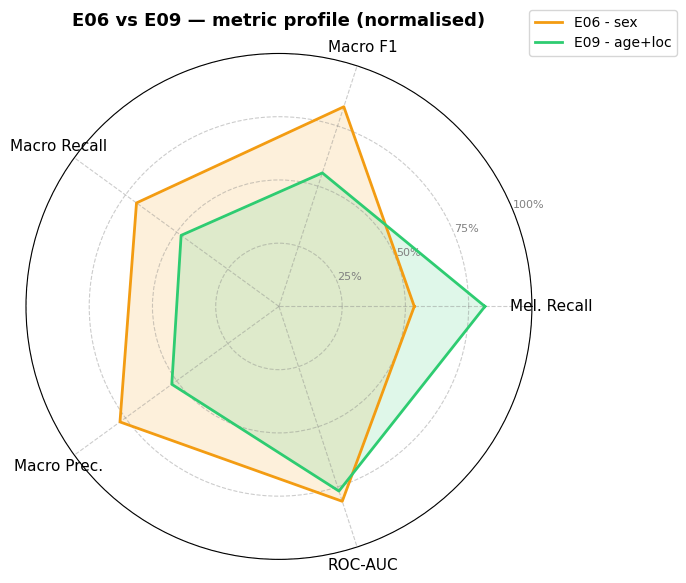

Figure saved.


In [10]:
# Radar chart — visual comparison E06 vs E09
metrics_radar = ["melanoma_recall", "macro_f1", "macro_recall", "macro_precision", "roc_auc"]
labels_radar  = ["Mel. Recall", "Macro F1", "Macro Recall", "Macro Prec.", "ROC-AUC"]

e06 = df[df["label"] == "E06 - sex"][metrics_radar].values[0]
e09 = df[df["label"] == "E09 - age+loc"][metrics_radar].values[0]

# Normalise between min and max of each metric for the radar
mins = np.array([0.60, 0.65, 0.75, 0.60, 0.94])
maxs = np.array([0.90, 0.85, 0.90, 0.85, 0.98])
e06_norm = (e06 - mins) / (maxs - mins)
e09_norm = (e09 - mins) / (maxs - mins)

angles = np.linspace(0, 2 * np.pi, len(metrics_radar), endpoint=False).tolist()
e06_norm = np.concatenate((e06_norm, [e06_norm[0]]))
e09_norm = np.concatenate((e09_norm, [e09_norm[0]]))
angles   = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, e06_norm, color="#f39c12", linewidth=2, label="E06 - sex")
ax.fill(angles, e06_norm, color="#f39c12", alpha=0.15)
ax.plot(angles, e09_norm, color="#2ecc71", linewidth=2, label="E09 - age+loc")
ax.fill(angles, e09_norm, color="#2ecc71", alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8, color="grey")
ax.set_title("E06 vs E09 — metric profile (normalised)",
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(color="grey", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "radar_e06_vs_e09.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Section 6: Multi-seed analysis — robustness validation

In [11]:
# Multi-seed summary table with mean and std
summary = df_seed.groupby("model")[["macro_f1", "roc_auc", "map", "melanoma_recall"]].agg(["mean", "std"])
summary.columns = ["_".join(col) for col in summary.columns]
summary = summary.round(4)

# Readable format: "mean ± std"
for metric in ["macro_f1", "roc_auc", "map", "melanoma_recall"]:
    summary[f"{metric}_fmt"] = summary.apply(
        lambda r: f"{r[f'{metric}_mean']:.4f} ± {r[f'{metric}_std']:.4f}", axis=1
    )

display(
    summary[["macro_f1_fmt", "roc_auc_fmt", "map_fmt", "melanoma_recall_fmt"]]
    .rename(columns={
        "macro_f1_fmt":        "Macro F1",
        "roc_auc_fmt":         "ROC-AUC",
        "map_fmt":             "mAP",
        "melanoma_recall_fmt": "Mel. Recall",
    })
    .style
    .set_caption("Multi-seed analysis — mean ± std (seeds 42, 123, 7)")
)

,Macro F1,ROC-AUC,mAP,Mel. Recall
model,,,,
E06,0.7717 ± 0.0487,0.9694 ± 0.0050,0.8596 ± 0.0247,0.7106 ± 0.0480
E09,0.7605 ± 0.0128,0.9710 ± 0.0009,0.8584 ± 0.0062,0.7525 ± 0.0831


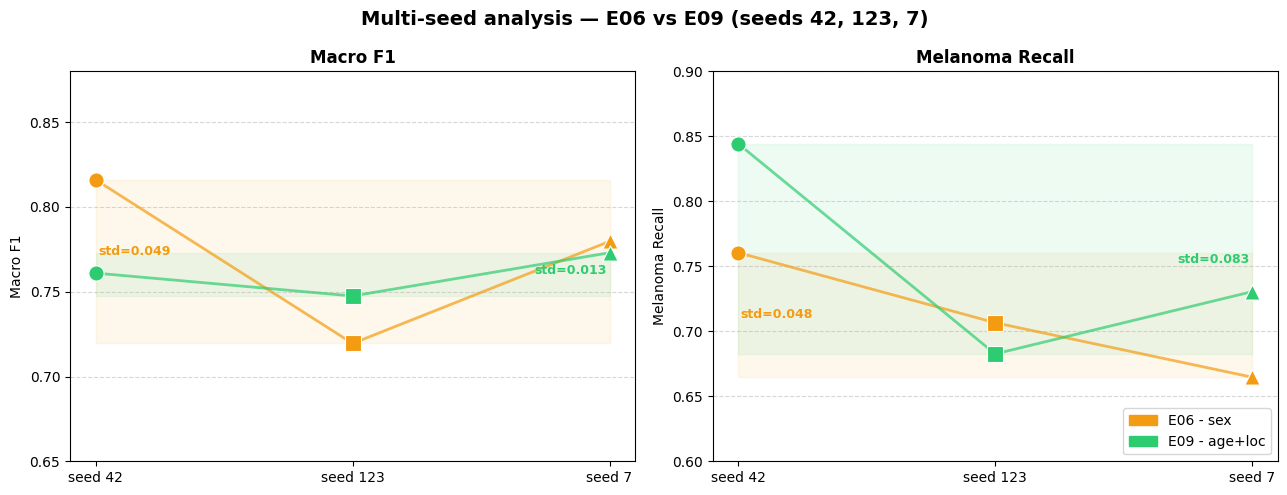

Figure saved.


In [13]:
# Plot: seed variability — E06 vs E09
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Multi-seed analysis — E06 vs E09 (seeds 42, 123, 7)",
             fontsize=14, fontweight="bold")

metrics_seed = [
    ("macro_f1",        "Macro F1",        0.65, 0.88),
    ("melanoma_recall", "Melanoma Recall",  0.60, 0.90),
]

colors_seed = {"E06": "#f39c12", "E09": "#2ecc71"}
markers     = {"seed 42": "o", "seed 123": "s", "seed 7": "^"}
seed_labels = ["seed 42", "seed 123", "seed 7"]

for ax, (metric, title, ymin, ymax) in zip(axes, metrics_seed):

    for model, color in colors_seed.items():
        model_data = df_seed[df_seed["model"] == model].copy()

        # Line connecting the 3 seeds
        vals = model_data.set_index("seed").loc[["seed 42", "seed 123", "seed 7"]].reset_index()[metric].values
        ax.plot([0, 1, 2], vals, color=color, linewidth=2, alpha=0.7)

        # Points per seed
        for i, (_, row) in enumerate(model_data.set_index("seed").loc[["seed 42", "seed 123", "seed 7"]].reset_index().iterrows()):
            ax.scatter(i, row[metric],
                       color=color, s=120, zorder=4,
                       marker=list(markers.values())[i],
                       edgecolors="white", linewidths=0.8,
                       label=f"{model} - {row['seed']}")

        # Variability band (min-max)
        ax.fill_between([0, 1, 2],
                        model_data.set_index("seed").loc[["seed 42", "seed 123", "seed 7"]].reset_index()[metric].min(),
                        model_data.set_index("seed").loc[["seed 42", "seed 123", "seed 7"]].reset_index()[metric].max(),
                        color=color, alpha=0.08)

        # Std annotation
        std_val  = model_data[metric].std()
        mean_val = model_data[metric].mean()
        x_pos = 0.15 if model == "E06" else 1.85
        ax.text(x_pos, mean_val, f"std={std_val:.3f}",
                color=color, fontsize=9, fontweight="bold", ha="center")

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["seed 42", "seed 123", "seed 7"], fontsize=10)
    ax.set_ylabel(title)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Unified legend
patch_e06 = mpatches.Patch(color="#f39c12", label="E06 - sex")
patch_e09 = mpatches.Patch(color="#2ecc71", label="E09 - age+loc")
axes[1].legend(handles=[patch_e06, patch_e09], loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "multiseed_e06_vs_e09.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Section 7: Per-class metrics — final model E09

In [15]:
# Extract per-class metrics for E09
clases = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

e09_row = df[df["label"] == "E09 - age+loc"].iloc[0]

per_class = pd.DataFrame({
    "Class":     clases,
    "Precision": [e09_row[f"{c}_precision"] for c in clases],
    "Recall":    [e09_row[f"{c}_recall"]    for c in clases],
    "F1":        [e09_row[f"{c}_f1"]        for c in clases],
    "AUC":       [e09_row[f"{c}_auc"]       for c in clases],
}).set_index("Class")

def highlight_mel(row):
    if row.name == "mel":
        return ["color: orange; font-weight: bold"] * len(row)
    return [""] * len(row)

def bold_max_class(s):
    is_best = s == s.max()
    return ["color: #1a7a1a; font-weight: bold" if v else "" for v in is_best]

display(
    per_class.style
    .apply(highlight_mel, axis=1)
    .apply(bold_max_class)
    .set_caption("Per-class metrics — E09 (seed=42)")
    .format("{:.4f}")
)

,Precision,Recall,F1,AUC
Class,,,,
akiec,0.5942,0.8367,0.6949,0.9767
bcc,0.7500,0.8961,0.8166,0.9912
bkl,0.7039,0.6485,0.6751,0.9465
df,0.8667,0.7647,0.8125,0.9918
mel,0.4534,0.8443,0.5900,0.9324
nv,0.9701,0.8072,0.8812,0.9565
vasc,0.7778,0.9545,0.8571,0.9995


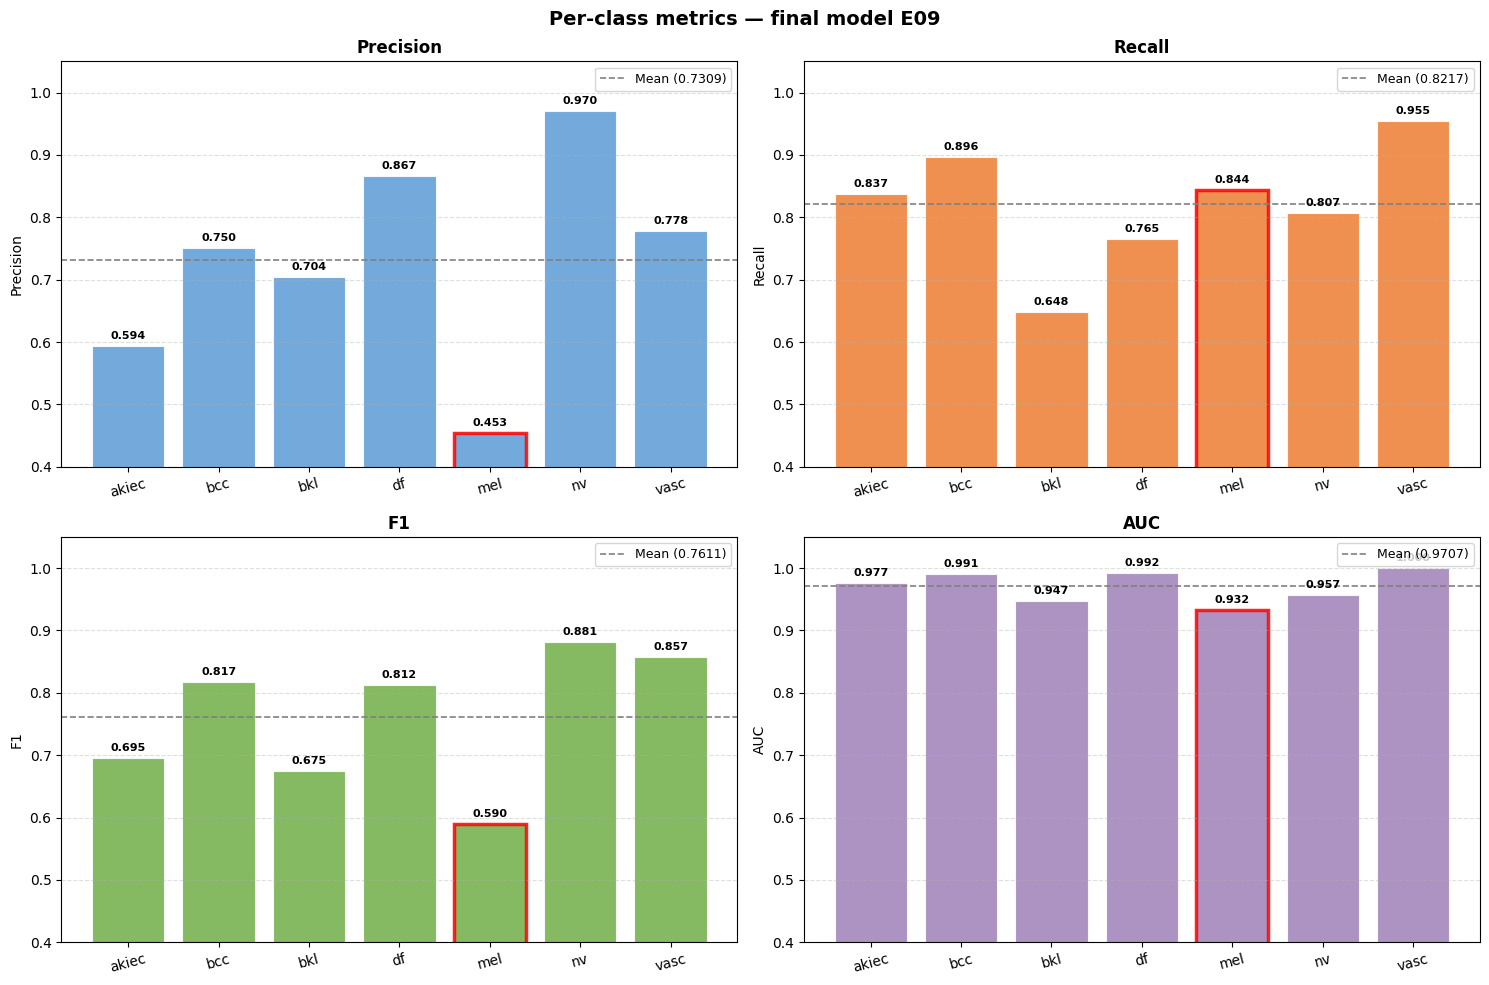

Figure saved.


In [17]:
# Grouped bar chart by class
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Per-class metrics — final model E09", fontsize=14, fontweight="bold")

metrics_class = [
    ("Precision", "#5b9bd5"),
    ("Recall",    "#ed7d31"),
    ("F1",        "#70ad47"),
    ("AUC",       "#9e80b8"),
]

for ax, (metric, color) in zip(axes.flatten(), metrics_class):
    bars = ax.bar(per_class.index, per_class[metric],
                  color=color, edgecolor="white", linewidth=0.8, alpha=0.85)

    # Highlight melanoma bar
    for i, (bar, clase) in enumerate(zip(bars, per_class.index)):
        if clase == "mel":
            bar.set_edgecolor("red")
            bar.set_linewidth(2.5)

    ax.axhline(per_class[metric].mean(), color="grey", linestyle="--",
               linewidth=1.2, label=f"Mean ({per_class[metric].mean():.4f})")

    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(0.4, 1.05)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend(fontsize=9)

    for bar, val in zip(bars, per_class[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "e09_per_class_metrics.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Section 8: Confusion matrix — final model E09

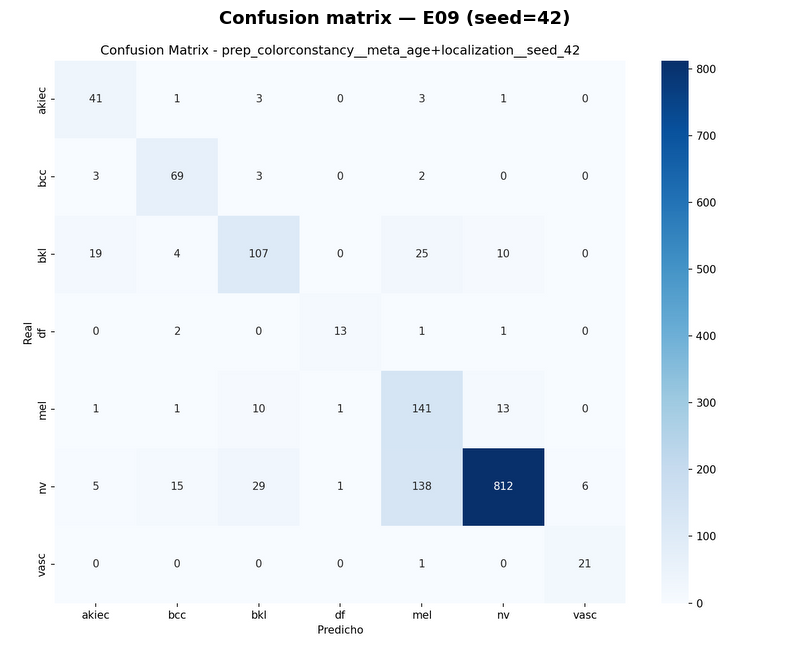

In [18]:
from PIL import Image

confusion_path = os.path.join(FIGURES_DIR, "prep_colorconstancy__meta_age+localization__seed_42_confusion_matrix.png")

if os.path.exists(confusion_path):
    img = Image.open(confusion_path)
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(img, interpolation="lanczos")
    ax.axis("off")
    ax.set_title("Confusion matrix — E09 (seed=42)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "e09_confusion_matrix_display.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Not found: {confusion_path}")

Matriz E09:

mel: 141 correctos de 167 totales — Recall 0.844 confirmado. Solo 13 melanomas clasificados como nv, que es el error más peligroso clínicamente.
nv: 812 correctos pero 138 clasificados como mel — esto explica la Precision baja de mel (0.453). El modelo es conservador: ante la duda clasifica como melanoma.
bkl: el más confundible, se dispersa entre akiec, mel y nv. Explica su Recall bajo (0.648).
vasc y df: casi perfectos, patrones muy distintivos.

Lo positivo:

nv está perfectamente identificado (812 correctos) — lógico, es la clase con más datos (6705 imágenes)
vasc tiene muy pocos errores (21/22 correctos) — sus patrones visuales son muy distintivos
df también funciona bien (13/17 correctos)
melanoma detecta 141 de 167 correctamente — Recall de 0.844, el más alto de toda la Fase 2

Lo que hay que remarcar como limitación:

El principal error crítico: mel se confunde con nv en 13 casos. Esto significa 13 melanomas clasificados como lunares benignos — los falsos negativos más peligrosos clínicamente. Es el error que más hay que mencionar en la memoria.
bkl es la clase más confundible: 19 errores hacia akiec, 25 hacia mel y 10 hacia nv. Tiene sentido porque la queratosis benigna comparte características visuales con varias clases.
akiec tiene 3 errores hacia mel — también relevante clínicamente porque ambas son lesiones potencialmente malignas.

Para la memoria te recomendaría escribir algo así:
markdownThe confusion matrix reveals that the most clinically critical error pattern 
is the misclassification of 13 melanoma cases as Melanocytic Nevi (nv) — 
false negatives that would go undetected in a clinical setting. This 
represents 7.8% of all melanoma test cases (13/167) and motivates the 
use of the uncertainty rejection mechanism in the Streamlit interface: 
ambiguous cases with confidence below 70% are flagged for specialist review 
rather than assigned a definitive diagnosis.

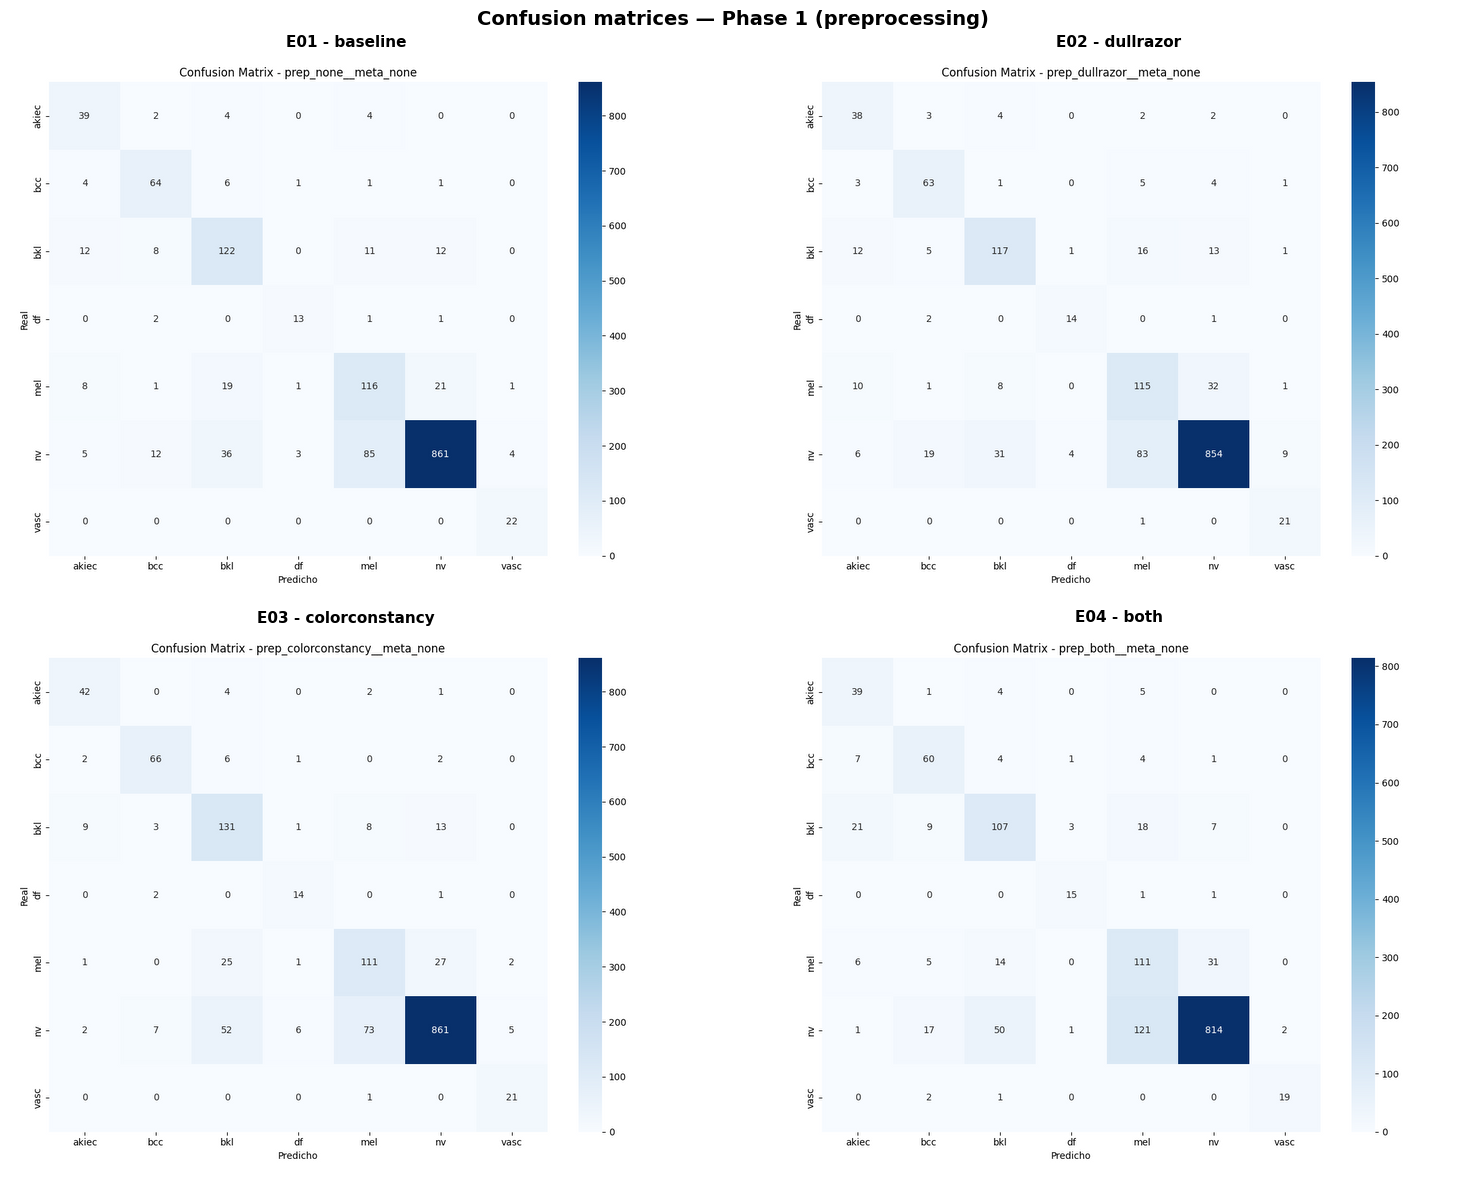

Figure saved.


In [19]:
# Confusion matrices Phase 1 — preprocessing comparison
fase1_experiments = [
    ("prep_none__meta_none",           "E01 - baseline"),
    ("prep_dullrazor__meta_none",      "E02 - dullrazor"),
    ("prep_colorconstancy__meta_none", "E03 - colorconstancy"),
    ("prep_both__meta_none",           "E04 - both"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Confusion matrices — Phase 1 (preprocessing)",
             fontsize=14, fontweight="bold")

for ax, (exp, label) in zip(axes.flatten(), fase1_experiments):
    path = os.path.join(FIGURES_DIR, f"{exp}_confusion_matrix.png")
    if os.path.exists(path):
        img = Image.open(path)
        ax.imshow(img, interpolation="lanczos")
        ax.axis("off")
        ax.set_title(label, fontsize=11, fontweight="bold", pad=8)
    else:
        ax.text(0.5, 0.5, f"Not found:\n{path}",
                ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fase1_confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

Matrices Fase 1:

Se ve claramente que E03 (colorconstancy) tiene la diagonal más consistente, especialmente en bkl (131 vs 122 del baseline). Justifica visualmente la selección.
El error nv→mel es sistemático en todos los preprocesados — no es un artefacto de E09.

## Section 9: Final conclusions

## Section 9: Conclusions

### Phase 1 — Preprocessing
- Color Constancy (E03) is the best preprocessing method: Macro F1 0.7700 and 
  Macro Recall 0.8295, superior to the baseline on both global metrics.
- DullRazor (E02) does not improve over the baseline: EfficientNet-B0 is 
  sufficiently robust to hair noise due to its ImageNet pretraining.
- Both (E04) is the worst preprocessing method: DullRazor inpainting introduces 
  artefacts that undo the Color Constancy normalisation.
- E03 does not achieve the best Melanoma Recall (0.665 vs 0.695 for the baseline) 
  — this limitation is addressed in Phase 2 through the incorporation of clinical 
  metadata.

### Phase 2 — Metadata
- E06 (sex) is the only metadata combination that improves Macro F1 over the 
  unimodal model (0.816 vs 0.770) with seed=42.
- E09 (age + localization) achieves the highest Melanoma Recall in the entire 
  project (0.844), a 27% improvement over the unimodal baseline (0.665).
- Localization alone (E07) yields the lowest Macro F1 (0.699) among all 
  Phase 2 experiments. Age+sex (E08) produces the lowest Melanoma Recall 
  (0.605) — even below the unimodal baseline (0.665) — suggesting that 
  combining age and sex without localization provides conflicting signals 
  that hurt melanoma detection.
- Adding all metadata (E11) does not guarantee the best result — the 
  age+localization combination outperforms age+sex+localization in Melanoma Recall.

### Multi-seed analysis
- E09 is four times more stable than E06 in Macro F1 (std 0.013 vs 0.049).
- With seed 123, E06 drops to Macro F1=0.720 — below the unimodal baseline E03 
  (0.770). This level of instability is unacceptable for a clinical decision 
  support system.
- E09 maintains a higher mean Melanoma Recall (0.753 vs 0.711) with a nearly 
  constant ROC-AUC across seeds (0.971 ± 0.001).
- The instability of E06 is explained by the limited signal of sex 
  (3 one-hot dimensions): depending on weight initialisation, the model 
  may treat it as noise rather than a meaningful feature.

### Final model — E09
- **Selected model**: E09 — Color Constancy + age + localization (seed=42).
- **Clinical justification**: age and anatomical localization are established 
  risk factors in oncological dermatology.
- **Technical justification**: superior multi-seed stability (std F1=0.013) 
  and highest mean Melanoma Recall (0.753).
- **Brier Score of 0.0426** — good probabilistic calibration, relevant for 
  the 70% uncertainty threshold in the Streamlit interface.
- Model weights saved at: 
  `outputs/models/prep_colorconstancy__meta_age+localization__seed_42_best.pth`